In [ ]:
#####start

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
df = pd.read_csv('Customer Churn.csv')

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
### now removing the totalcharges column blanks field with the zero
df["TotalCharges"] = df["TotalCharges"].replace(" ",0)
df["Total Charges"] = df["TotalCharges"].astype("float")

In [16]:
###monthly charges now converted to float (verified)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Checking the column which connains the null value and sum up 


In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,Total Charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
#checking the dublicate value 

In [15]:
df.duplicated().sum()

np.int64(0)

checking the dublicte on the basic of unique code that is customer id


In [18]:
df["customerID"].duplicated().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

now changing the senior citizen column value 0 and 1 to yes and no. i will write the function below for this  

In [22]:
def conv(value):
    if value ==1:
        return"yes"
    else:
        return "no"

df['SeniorCitizen'] =df["SeniorCitizen"].apply(conv)

okay now i will check the first 40 rows and see the value in senior citizen is changed or not

In [25]:
df.head(40)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total Charges
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,1889.50
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65
5,9305-CDSKC,Female,no,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,820.50
6,1452-KIOVK,Male,no,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No,1949.40
7,6713-OKOMC,Female,no,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No,301.90
8,7892-POOKP,Female,no,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,3046.05
9,6388-TABGU,Male,no,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,3487.95


generate the customer number who churn the company and who are still in the company

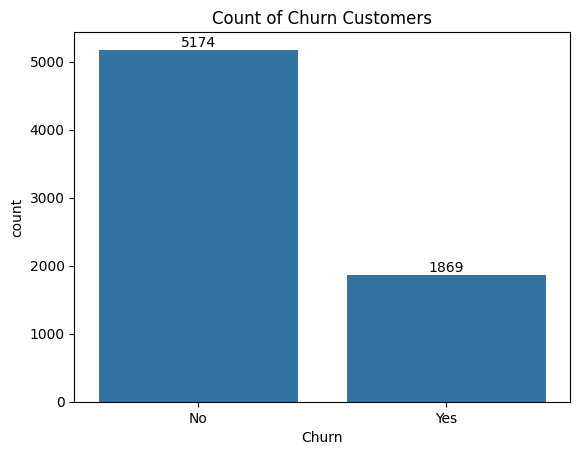

In [37]:
ax = sns.countplot(x='Churn', data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Churn Customers")
plt.show()

now i will also show in percentage 

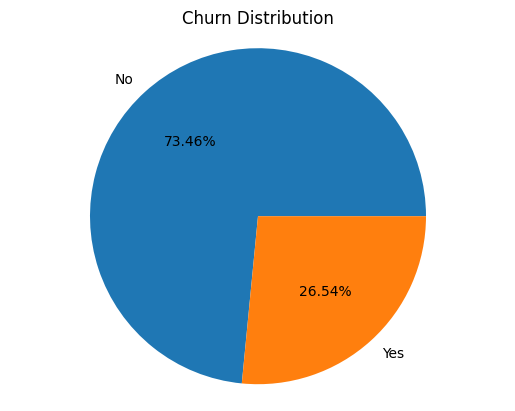

In [36]:
counts = df['Churn'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.2f%%')
plt.title("Churn Distribution")
plt.axis('equal')

plt.show()

as we can see theat 26.54% of customers are churn out

now i will explore on the basics of gender

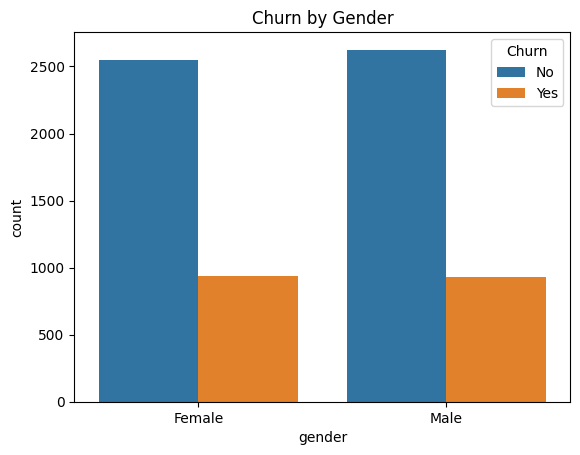

In [42]:
plt.Figure(figsize=(4,5))
sns.countplot(x="gender", data=df,  hue="Churn")
plt.title('Churn by Gender')
plt.show()


Senior citizen 

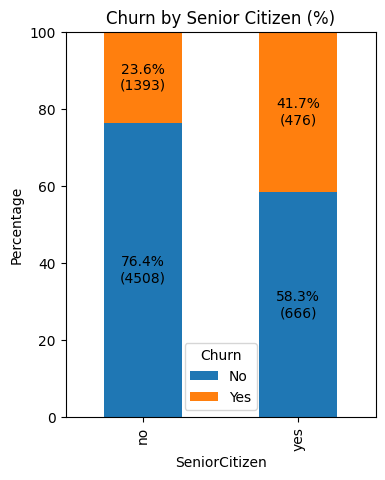

In [53]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_percent.plot(kind='bar', stacked=True, figsize=(4,5))

# Loop through containers (each stacked category)
for i, container in enumerate(ax.containers):
    labels = []
    
    for j, v in enumerate(container.datavalues):
        count = ct.iloc[j, i]
        
        if v > 0:
            labels.append(f'{v:.1f}%\n({count})')
        else:
            labels.append('')
    
    ax.bar_label(container, labels=labels, label_type='center')

plt.title('Churn by Senior Citizen (%)')
plt.ylabel('Percentage')
plt.xlabel('SeniorCitizen')
plt.ylim(0, 100)

plt.legend(title='Churn')
plt.show()

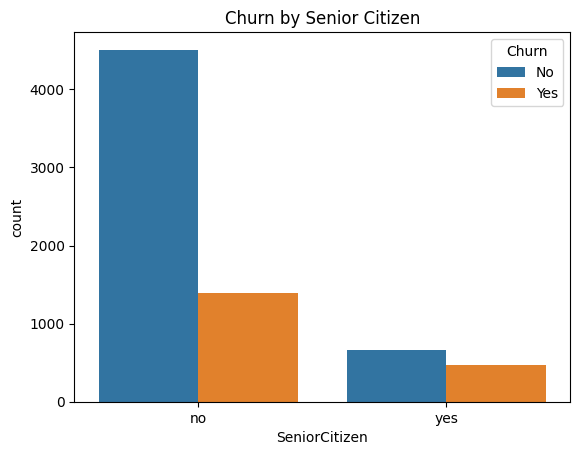

In [54]:
plt.Figure(figsize=(4,5)) 
sns.countplot(x="SeniorCitizen", data=df, hue="Churn") 
plt.title('Churn by Senior Citizen') 
plt.show()

for the count of senior citizen 


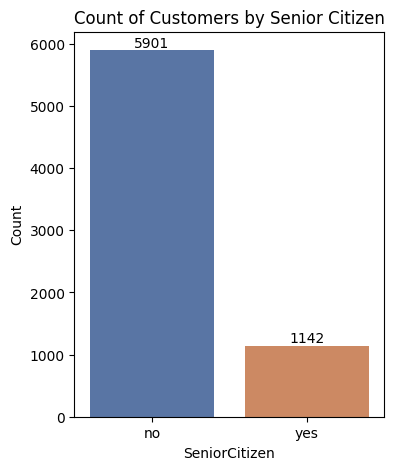

In [64]:
plt.figure(figsize=(4,5))

ax = sns.countplot(
    x="SeniorCitizen",
    hue="SeniorCitizen",
    data=df,
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title("Count of Customers by Senior Citizen")
plt.ylabel("Count")

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

greater percentage  of people in senior citixzen category have churned out

now i will plot the histogram according to tenure 

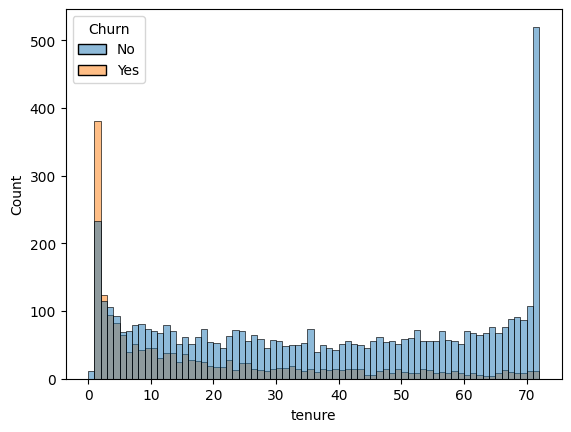

In [66]:
plt.Figure(figsize=(9,5))
sns.histplot(x="tenure", data = df, bins = 72, hue = 'Churn')
plt.show()

people who have used services for long time has stayed and people who has used services for 1/2 month have highly churned out

Now  want to check from the count of contract basics

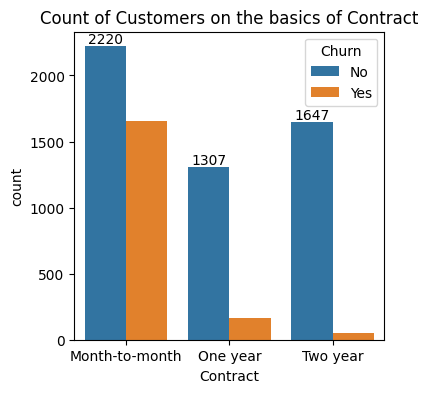

In [68]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="Contract", data=df, hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers on the basics of Contract")
plt.show()

people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [69]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn',
    'Total Charges']
Length: 22, dtype: str

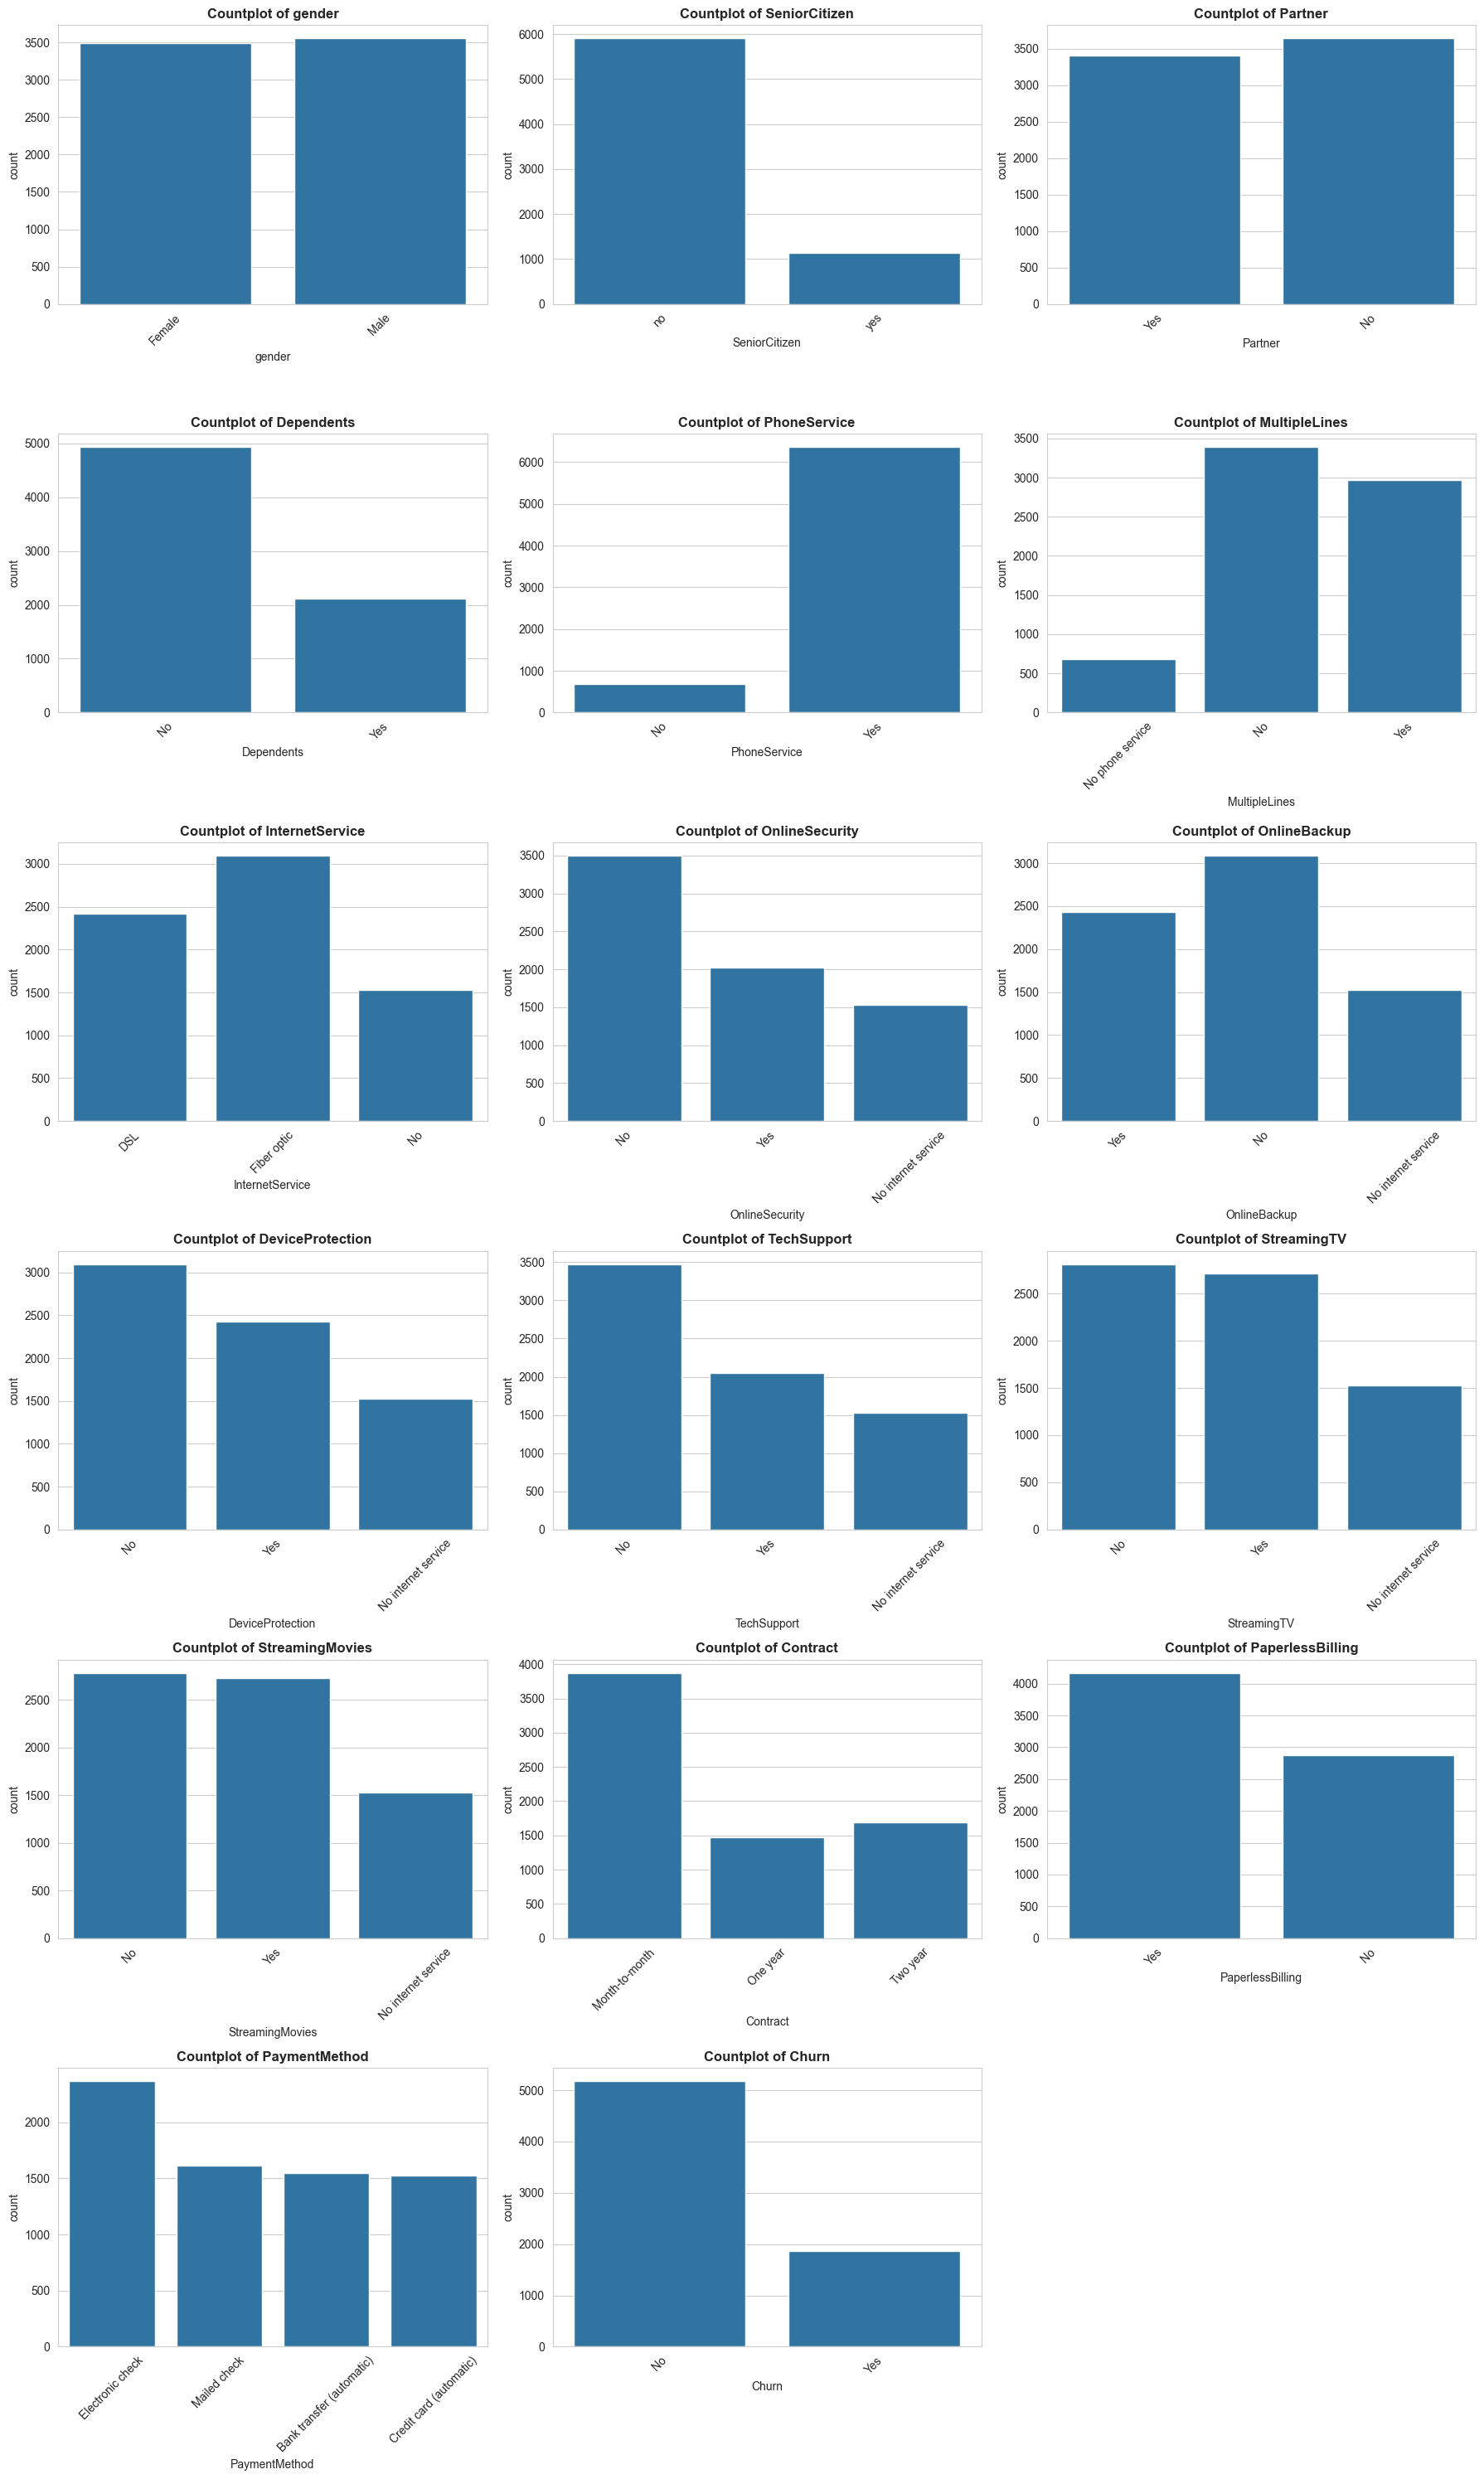

In [76]:
import math

# ----------------------------
# 1️⃣ Clean Column Names
# ----------------------------

# Remove duplicate column if it exists
df = df.drop(columns=['Total Charges'], errors='ignore')

# Strip spaces from column names (important!)
df.columns = df.columns.str.strip()

# ----------------------------
# 2️⃣ Convert Data Types Properly
# ----------------------------

# Convert all columns to best possible dtypes
df = df.convert_dtypes()

# Convert TotalCharges to numeric if needed
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ----------------------------
# 3️⃣ Select Categorical Columns (Future-Proof)
# ----------------------------

cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

# Remove customerID since it's unique
cat_cols = cat_cols.drop('customerID', errors='ignore')

# print("Categorical Columns:")
# print(cat_cols)

# ----------------------------
# 4️⃣ Create Countplots as Subplots
# ----------------------------

sns.set_style("whitegrid")

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

now i will try it on the basics of churn adding hue as churn

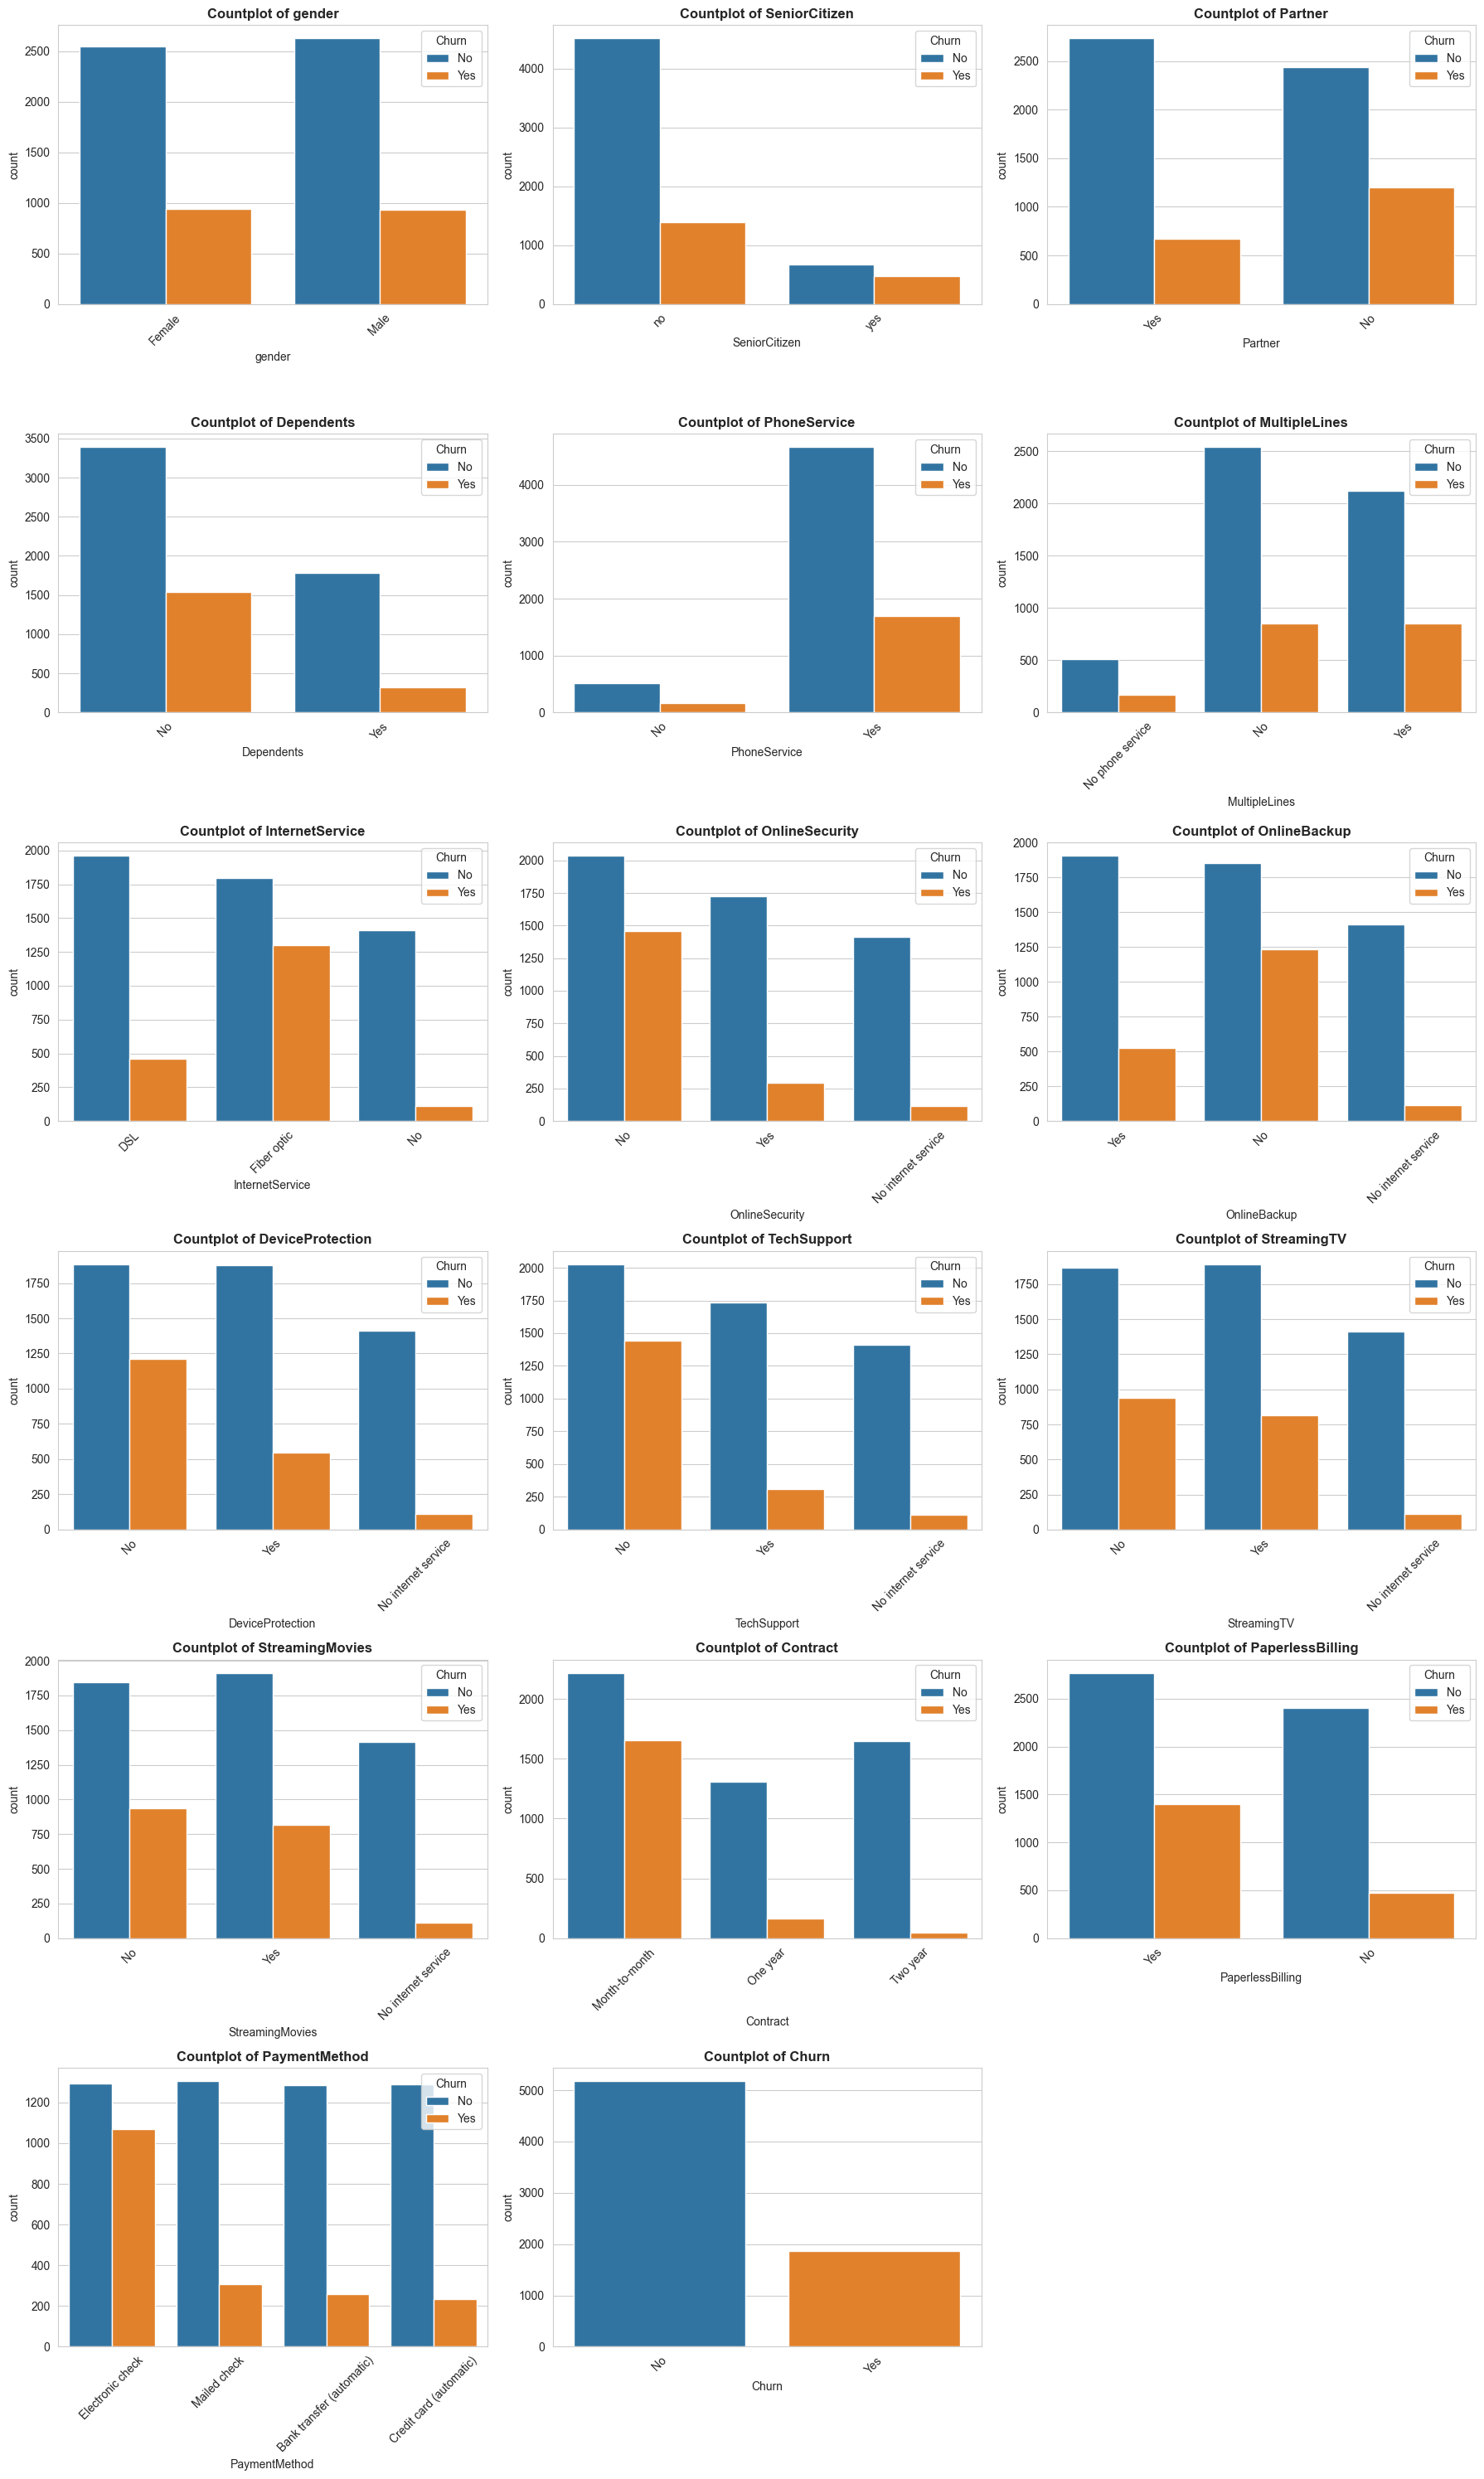

In [75]:
import math

# ----------------------------
# 1️⃣ Clean Column Names
# ----------------------------

# Remove duplicate column if it exists
df = df.drop(columns=['Total Charges'], errors='ignore')

# Strip spaces from column names (important!)
df.columns = df.columns.str.strip()

# ----------------------------
# 2️⃣ Convert Data Types Properly
# ----------------------------

# Convert all columns to best possible dtypes
df = df.convert_dtypes()

# Convert TotalCharges to numeric if needed
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ----------------------------
# 3️⃣ Select Categorical Columns (Future-Proof)
# ----------------------------

cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns

# Remove customerID since it's unique
cat_cols = cat_cols.drop('customerID', errors='ignore')

# print("Categorical Columns:")
# print(cat_cols)

# ----------------------------
# 4️⃣ Create Countplots as Subplots
# ----------------------------

sns.set_style("whitegrid")

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue = df['Churn'])
    axes[i].set_title(f'Countplot of {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Customer churn appears fairly similar across genders, indicating gender is not a strong predictor of churn. Senior citizens show a noticeably higher churn rate compared to non-senior customers. Customers without partners or dependents tend to churn more frequently.

Service-related factors show strong impact: customers using Fiber optic internet and those without Online Security, Tech Support, or Device Protection have significantly higher churn rates, while customers with added services and support features are more likely to stay.

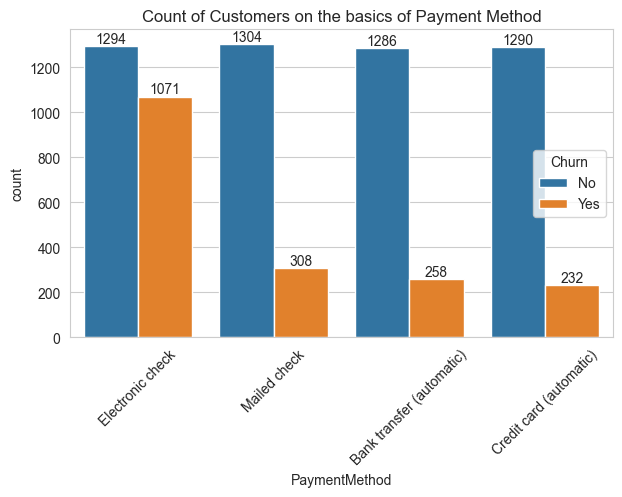

In [82]:
plt.figure(figsize=(7,4))
ax = sns.countplot(x="PaymentMethod", data=df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Count of Customers on the basics of Payment Method")
plt.xticks(rotation=45)
plt.show()